In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import zipfile

zip_path = '/content/drive/MyDrive/cats-dogs-project/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzipping!")

Done unzipping!


In [32]:
import os

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show files in first 2 levels
        for file in files[:3]:  # show just first 3 files as sample
            print(f'{indent}  {file}')


data/
  test/
    dogs/
    cats/
  PetImages/
    Cat/
    Dog/
  train/
    dogs/
    cats/
  validation/
    dogs/
    cats/


In [33]:
import os, shutil, random

cats_dir = '/content/data/PetImages/Cat'
dogs_dir = '/content/data/PetImages/Dog'

base = '/content/drive/MyDrive/cats-dogs-project/data'

for split in ['train', 'validation', 'test']:
    for category in ['cats', 'dogs']:
        os.makedirs(f'{base}/{split}/{category}', exist_ok=True)

def split_and_copy(src_dir, category):
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.shuffle(files)
    n = len(files)

    splits = {
        'train':      files[:int(0.8 * n)],
        'validation': files[int(0.8 * n):int(0.9 * n)],
        'test':       files[int(0.9 * n):]
    }

    for split, filelist in splits.items():
        for fname in filelist:
            shutil.copy(f'{src_dir}/{fname}', f'{base}/{split}/{category}/{fname}')

    print(f'{category} done')

split_and_copy(cats_dir, 'cats')
split_and_copy(dogs_dir, 'dogs')

cats done
dogs done


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize pixel values from 0-255 to 0.0-1.0
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/cats-dogs-project/data/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
# same for val and test

val_generator = val_datagen.flow_from_directory(
    '/content/data/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/data/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 24018 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


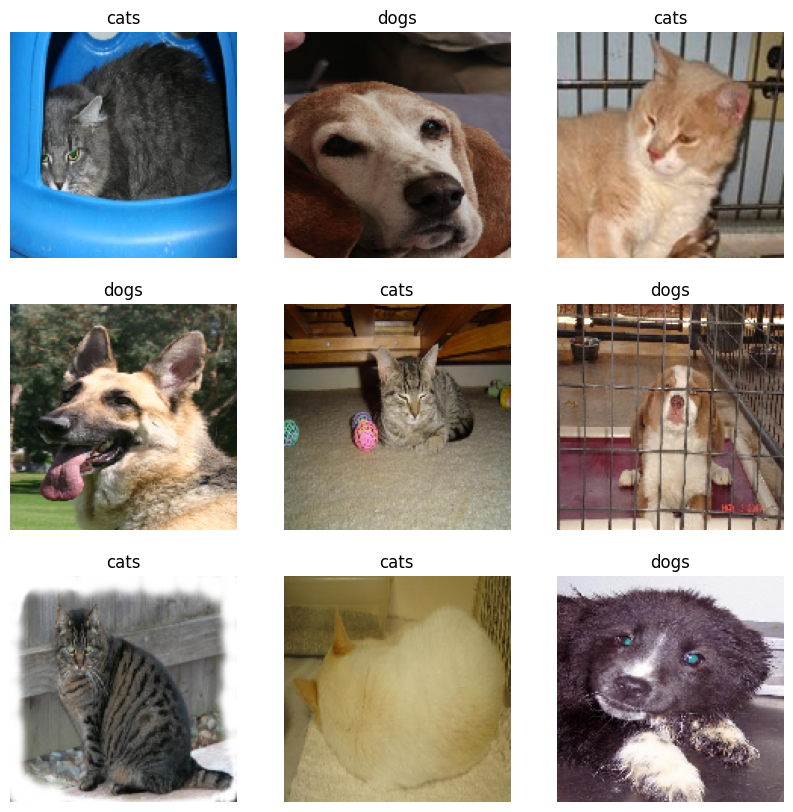

In [35]:
import matplotlib.pyplot as plt

# Grab one batch of images and their labels
images, labels = next(train_generator)

class_names = ['cats', 'dogs']

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()
